In [ ]:
import os
import sys
import requests
import shutil
import time
import random

# ==========================================
# 1. Visual-Clutter 라이브러리 설정
# ==========================================
# 기존 폴더 정리
if os.path.exists('visual-clutter'):
    shutil.rmtree('visual-clutter')

try:
    import pyrtools
    print("   ✅ pyrtools 이미 설치됨")
except ImportError:
    print("   ⬇️ pyrtools 설치 중...")
    !pip install pyrtools

# 라이브러리 다운로드
!git clone https://github.com/kargaranamir/visual-clutter.git

# 경로 추가
if '/content/visual-clutter' not in sys.path:
    sys.path.append('/content/visual-clutter')

print("✅ Visual-Clutter 라이브러리 소스 다운로드 완료")

# ==========================================
# 2. LLD 데이터셋 대체 (User-Agent 헤더 추가)
# ==========================================
DATA_DIR = '/content/lld_dataset' # 절대 경로 사용

# 폴더가 없으면 생성, 있으면 내부 비우기 (깨끗한 시작)
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)

# 브라우저인 척 하기 위한 헤더
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'Referer': 'https://www.google.com/'
}

# 흑백 이미지
sample_urls = [
   ("https://upload.wikimedia.org/wikipedia/commons/thumb/f/fa/Apple_logo_black.svg/488px-Apple_logo_black.svg.png", "apple.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/a/a6/Logo_NIKE.svg/600px-Logo_NIKE.svg.png", "nike.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/2/20/Adidas_Logo.svg/600px-Adidas_Logo.svg.png", "adidas.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/c/c2/GitHub_Invertocat_Logo.svg/600px-GitHub_Invertocat_Logo.svg.png", "github.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/3/35/Tux.svg/512px-Tux.svg.png", "linux_tux.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/3/32/Mercedes-Benz_Star_2022.svg/600px-Mercedes-Benz_Star_2022.svg.png", "mercedes_star.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/9/92/Audi-Logo_2016.svg/600px-Audi-Logo_2016.svg.png", "audi_rings.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/b/b7/Renault_2021_Textless_logo.svg/600px-Renault_2021_Textless_logo.svg.png", "renault_diamond.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/5/53/X_logo_2023_original.svg/600px-X_logo_2023_original.svg.png", "x_logo.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/The_North_Face_logo.svg/600px-The_North_Face_logo.svg.png", "northface.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/9/91/Vans-logo.svg/600px-Vans-logo.svg.png", "vans.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/1/17/Yin_yang.svg/600px-Yin_yang.svg.png", "yin_yang.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/0/0b/Radiation_warning_symbol.svg/600px-Radiation_warning_symbol.svg.png", "radiation.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/8/8e/Peace_symbol.svg/600px-Peace_symbol.svg.png", "peace_sign.png"),
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/4/44/Recycle001.svg/600px-Recycle001.svg.png", "recycle.png")
]

print(f"Downloading {len(sample_urls)} images to {DATA_DIR}...\n")
print("⚠️ 주의: 차단 방지를 위해 이미지마다 3~6초씩 대기합니다. 조금 오래 걸려도 기다려주세요.\n")

success_count = 0
for i, (url, filename) in enumerate(sample_urls):
    save_path = os.path.join(DATA_DIR, filename)

    # 이미 잘 다운로드된 파일은 건너뛰기 (시간 절약)
    if os.path.exists(save_path) and os.path.getsize(save_path) > 1000:
        print(f"[{i+1}/{len(sample_urls)}] ⏭️ Skip (Already exists): {filename}")
        success_count += 1
        continue

    try:
        # [핵심] 차단 방지를 위한 긴 대기 시간 (3 ~ 6초)
        sleep_time = random.uniform(3.0, 6.0)
        time.sleep(sleep_time)

        response = requests.get(url, headers=headers, stream=True, timeout=15)

        if response.status_code == 200:
            with open(save_path, 'wb') as f:
                f.write(response.content)
            print(f"[{i+1}/{len(sample_urls)}] ✅ Success: {filename}")
            success_count += 1

        elif response.status_code == 429:
            print(f"[{i+1}/{len(sample_urls)}] ⛔ Too Fast (429): {filename}")
            print("   -> 🚨 20초간 긴급 대기 후 넘어갑니다...")
            time.sleep(20) # 429 발생 시 아주 길게 쉬기

        elif response.status_code == 404:
            print(f"[{i+1}/{len(sample_urls)}] ❌ Not Found (404): {filename} (링크가 만료됨)")

        else:
            print(f"[{i+1}/{len(sample_urls)}] ❌ Fail ({response.status_code}): {filename}")

    except Exception as e:
        print(f"[{i+1}/{len(sample_urls)}] ❌ Error: {e}")

print(f"\n✅ 최종 완료: {success_count} / {len(sample_urls)}")
print("👉 다운로드가 끝나면 [Step 2] 코드를 실행하세요.")

   ✅ pyrtools 이미 설치됨
Cloning into 'visual-clutter'...
remote: Enumerating objects: 1428, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 1428 (delta 28), reused 5 (delta 4), pack-reused 1380 (from 1)
Receiving objects: 100% (1428/1428), 13.46 MiB | 16.71 MiB/s, done.
Resolving deltas: 100% (345/345), done.
✅ Visual-Clutter 라이브러리 소스 다운로드 완료

⚠️ 주의: 차단 방지를 위해 이미지마다 3~6초씩 대기합니다. 조금 오래 걸려도 기다려주세요.

[1/15] ✅ Success: apple.png
[2/15] ✅ Success: nike.png
[3/15] ✅ Success: adidas.png
[4/15] ✅ Success: github.png
[5/15] ✅ Success: linux_tux.png
[6/15] ✅ Success: mercedes_star.png
[7/15] ✅ Success: audi_rings.png
[8/15] ❌ Not Found (404): renault_diamond.png (링크가 만료됨)
[9/15] ✅ Success: x_logo.png
[10/15] ❌ Not Found (404): northface.png (링크가 만료됨)
[11/15] ✅ Success: vans.png
[12/15] ✅ Success: yin_yang.png
[13/15] ✅ Success: radiation.png
[14/15] ❌ Not Found (404): peace_sign.png (링크가 만료됨)
[15/15] ✅ Success: recycle.png

✅ 최종 완료:


✅ 12개의 이미지를 분석합니다...

Image Name      | Tex(H)   | Col(H)   | My Algo  | Feature Congestion
---------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


github.png      | 0.000    | 0.000    | 0.000    | 3.4263
linux_tux.png   | 3.562    | 1.799    | 2.680    | 3.9011
mercedes_star.p | 3.137    | 1.844    | 2.491    | 4.2457
vans.png        | 1.095    | 1.208    | 1.151    | 6.9230


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


apple.png       | 0.000    | 0.000    | 0.000    | 2.7970
yin_yang.png    | 1.050    | 1.033    | 1.041    | 3.4722


...

adidas.png      | 0.000    | 0.000    | 0.000    | 5.3963


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


audi_rings.png  | 0.000    | 0.000    | 0.000    | 7.6518
radiation.png   | 0.942    | 0.941    | 0.942    | 2.1673
recycle.png     | 1.100    | 1.126    | 1.113    | 4.2686


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


nike.png        | 0.000    | 0.000    | 0.000    | 3.5400


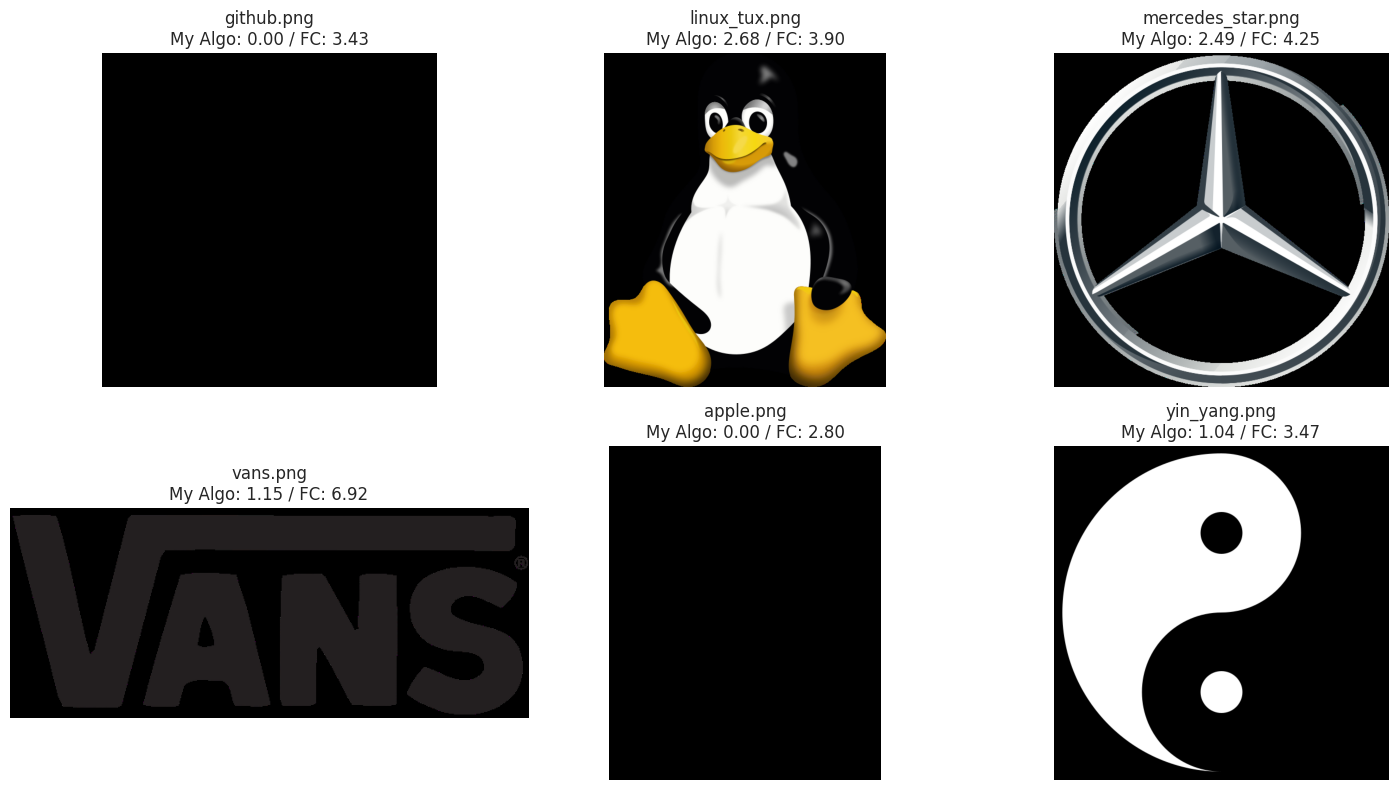

In [ ]:
import os
import sys
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.stats import entropy
from PIL import Image

# ==========================================
# [필수] 라이브러리 경로 확인
# ==========================================
# 다운로드 받은 폴더를 파이썬 경로에 추가
if '/content/visual-clutter' not in sys.path:
    sys.path.append('/content/visual-clutter')

# ==========================================
# 1. Feature Congestion (클래스명 Vlc로 수정됨)
# ==========================================
def preprocess_and_calculate_fc(original_image_path):
    try:
        # [수정 1] 실제 파일 확인 결과, 클래스명은 'Vclutter'가 아니라 'Vlc'였습니다.
        from visual_clutter.clutter import Vlc

        # 1. 이미지 로드
        img = Image.open(original_image_path)

        # 2. 전처리: 투명 배경(Alpha)이 있는 경우 흰색 배경으로 병합
        # (Feature Congestion 알고리즘은 투명도를 처리하지 못해 0점이 나오는 문제 방지)
        if img.mode in ('RGBA', 'LA') or (img.mode == 'P' and 'transparency' in img.info):
            background = Image.new("RGB", img.size, (255, 255, 255))
            if img.mode != 'RGBA':
                img = img.convert('RGBA')
            background.paste(img, mask=img.split()[3])
            clean_img = background
        else:
            clean_img = img.convert("RGB")

        # 3. 임시 파일 저장 (라이브러리가 파일 경로를 입력받기 때문)
        temp_path = "temp_for_fc.jpg"
        clean_img.save(temp_path, "JPEG", quality=95)

        # 4. 계산 실행
        # [수정 2] 클래스 생성자도 Vlc로 변경
        clt = Vlc(temp_path)
        score, _ = clt.getClutter_FC()

        return score

    except ImportError as e:
        print(f"❌ Import 실패: {e}")
        return 0.0
    except Exception as e:
        # 상세한 에러 메시지 출력
        print(f"⚠️ FC Error ({os.path.basename(original_image_path)}): {e}")
        return 0.0

# ==========================================
# 2. Custom Entropy (Texture + Color)
# ==========================================
def calculate_texture_entropy(image_np):
    # Grayscale 변환
    if len(image_np.shape) == 3:
        gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    else:
        gray = image_np

    # 히스토그램 엔트로피 계산
    hist, _ = np.histogram(gray.flatten(), bins=256, range=[0, 256])
    prob_dist = hist / (hist.sum() + 1e-10) # 0 나누기 방지
    return entropy(prob_dist, base=2)

def calculate_color_entropy(image_np, k=5):
    # K-Means를 이용한 색상 분포 엔트로피
    # 속도를 위해 이미지 크기 축소 (150x150)
    resized = cv2.resize(image_np, (150, 150))
    pixels = resized.reshape(-1, 3)

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(pixels)

    counts = np.bincount(kmeans.labels_, minlength=k)
    prob_dist = counts / (counts.sum() + 1e-10)
    return entropy(prob_dist, base=2)

def calculate_hybrid_entropy(image_np, alpha=0.5, beta=0.5):
    # 제안 알고리즘: Texture와 Color 엔트로피의 선형 결합
    tex = calculate_texture_entropy(image_np)
    col = calculate_color_entropy(image_np, k=8)
    return (alpha * tex) + (beta * col), tex, col

# ==========================================
# 3. Main 실행
# ==========================================
if __name__ == "__main__":
    BASE_DIR = '/content/lld_dataset'
    image_paths = glob.glob(os.path.join(BASE_DIR, '*'))

    # 이미지 파일만 필터링
    valid_extensions = ('.png', '.jpg', '.jpeg', '.svg')
    image_paths = [p for p in image_paths if p.lower().endswith(valid_extensions)]

    if not image_paths:
        print(f"❌ '{BASE_DIR}' 경로에 이미지가 없습니다. Step 1(다운로드)을 먼저 실행해주세요.")
    else:
        print(f"\n✅ {len(image_paths)}개의 이미지를 분석합니다...\n")
        print(f"{'Image Name':<15} | {'Tex(H)':<8} | {'Col(H)':<8} | {'My Algo':<8} | {'Feature Congestion':<18}")
        print("-" * 75)

        results = []

        for path in image_paths:
            name = os.path.basename(path)
            try:
                # 1. Feature Congestion (Vlc 사용)
                fc_score = preprocess_and_calculate_fc(path)

                # 2. Custom Algorithm (제안 알고리즘)
                img_pil = Image.open(path).convert('RGB')
                img_np = np.array(img_pil)
                hybrid, tex, col = calculate_hybrid_entropy(img_np)

                results.append({'img': img_np, 'name': name, 'hybrid': hybrid, 'fc': fc_score})

                print(f"{name[:15]:<15} | {tex:.3f}    | {col:.3f}    | {hybrid:.3f}    | {fc_score:.4f}")

            except Exception as e:
                print(f"Error processing {name}: {e}")

        # 결과 시각화
        if results:
            plt.figure(figsize=(15, 8))
            for i, res in enumerate(results[:6]): # 최대 6개까지만 표시
                plt.subplot(2, 3, i+1)
                plt.imshow(res['img'])
                plt.title(f"{res['name']}\nMy Algo: {res['hybrid']:.2f} / FC: {res['fc']:.2f}")
                plt.axis('off')
            plt.tight_layout()
            plt.show()


📊 [순위 기반 분석 결과]
1. 스피어만 상관계수 (Rank Correlation) : 0.2090 (p-value: 0.5144)
2. 켄달 타우 (Concordance Rate)       : 0.1207 (p-value: 0.6061)
------------------------------------------------------------

🏆 [Top-5 복잡도 이미지 비교]
   -> FC가 뽑은 Top-5: ['mercedes_star.png', 'adidas.png', 'vans.png', 'audi_rings.png', 'recycle.png']
   -> 내가 뽑은 Top-5: ['mercedes_star.png', 'yin_yang.png', 'vans.png', 'recycle.png', 'linux_tux.png']
   -> 일치하는 이미지 (3개): ['recycle.png', 'mercedes_star.png', 'vans.png']
   🔥 Top-5 일치율: 60.0%


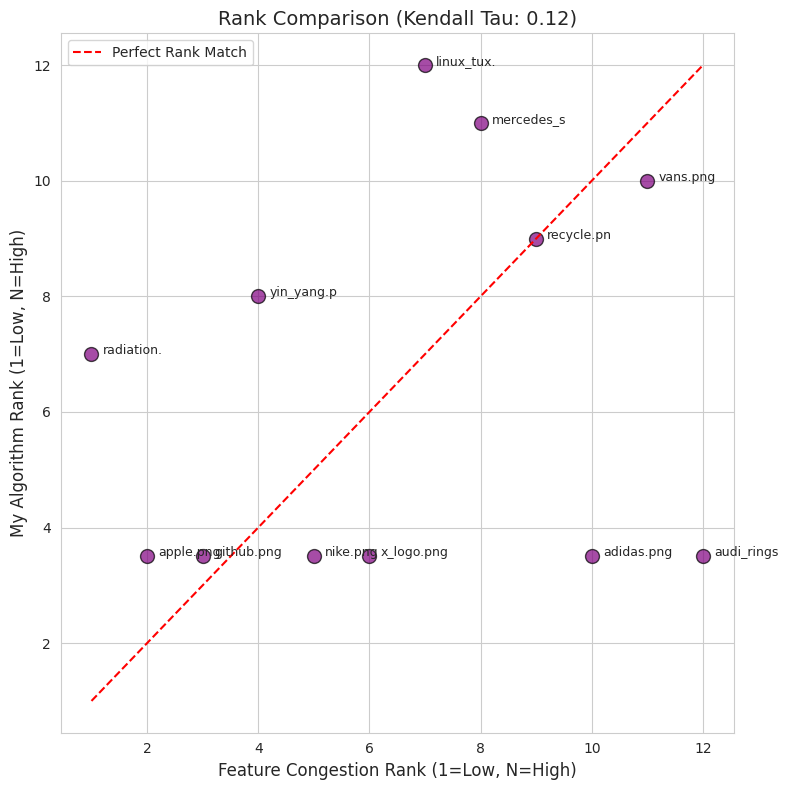

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_ranking_performance(results_data, top_k=5):
    """
    순위(Ranking) 관점에서 두 알고리즘을 비교하는 분석 함수
    """
    if not results_data or len(results_data) < 2:
        print("❌ 데이터가 부족합니다.")
        return

    # 1. 데이터 추출
    names = [item['name'] for item in results_data]
    fc_scores = np.array([item['fc'] for item in results_data])
    my_scores = np.array([item['hybrid'] for item in results_data])

    # 2. 순위 기반 상관계수 계산
    # (1) 스피어만 (전체적인 순위 경향성)
    spearman_corr, spearman_p = stats.spearmanr(fc_scores, my_scores)

    # (2) 켄달 타우 (두 이미지를 골랐을 때 대소 관계가 일치할 확률) -> 추천!
    kendall_corr, kendall_p = stats.kendalltau(fc_scores, my_scores)

    print("\n📊 [순위 기반 분석 결과]")
    print("=" * 60)
    print(f"1. 스피어만 상관계수 (Rank Correlation) : {spearman_corr:.4f} (p-value: {spearman_p:.4f})")
    print(f"2. 켄달 타우 (Concordance Rate)       : {kendall_corr:.4f} (p-value: {kendall_p:.4f})")
    print("-" * 60)

    # 3. Top-K 일치율 분석 (실무적으로 가장 중요)
    # 점수가 높은 순서대로 인덱스 정렬
    fc_top_indices = np.argsort(fc_scores)[::-1][:top_k]
    my_top_indices = np.argsort(my_scores)[::-1][:top_k]

    fc_top_names = set([names[i] for i in fc_top_indices])
    my_top_names = set([names[i] for i in my_top_indices])

    intersection = fc_top_names.intersection(my_top_names)
    overlap_score = len(intersection) / top_k * 100

    print(f"\n🏆 [Top-{top_k} 복잡도 이미지 비교]")
    print(f"   -> FC가 뽑은 Top-{top_k}: {list(fc_top_names)}")
    print(f"   -> 내가 뽑은 Top-{top_k}: {list(my_top_names)}")
    print(f"   -> 일치하는 이미지 ({len(intersection)}개): {list(intersection)}")
    print(f"   🔥 Top-{top_k} 일치율: {overlap_score:.1f}%")
    print("=" * 60)

    # 4. 순위 산점도 (Rank-Rank Plot)
    # 점수 자체가 아니라 '등수'를 비교합니다.
    fc_ranks = stats.rankdata(fc_scores)
    my_ranks = stats.rankdata(my_scores)

    plt.figure(figsize=(8, 8))
    sns.set_style("whitegrid")

    plt.scatter(fc_ranks, my_ranks, s=100, color='purple', alpha=0.7, edgecolors='k')

    # 텍스트 태깅
    for i, name in enumerate(names):
        plt.text(fc_ranks[i]+0.2, my_ranks[i], name[:10], fontsize=9)

    # y=x (순위가 완벽히 일치하면 이 선 위에 점이 찍힘)
    max_rank = len(names)
    plt.plot([1, max_rank], [1, max_rank], 'r--', label='Perfect Rank Match')

    plt.title(f'Rank Comparison (Kendall Tau: {kendall_corr:.2f})', fontsize=14)
    plt.xlabel('Feature Congestion Rank (1=Low, N=High)', fontsize=12)
    plt.ylabel('My Algorithm Rank (1=Low, N=High)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 실행
if __name__ == "__main__":
    if 'results' in locals() and results:
        analyze_ranking_performance(results, top_k=5)